In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# ==============================================================================
# AUDIT CELL: HIGH-FIDELITY DISK PATH DISCOVERY & ENVIRONMENT VERIFICATION
# Objective: Scan the Kaggle container mount tree to extract the exact physical 
# absolute paths of your production dimensions and facts Parquet assets.
# ==============================================================================

import os

print("=== INITIATING PHYSICAL INFRASTRUCTURE AUDIT ===")
print(f" -> Active Working Directory: {os.getcwd()}")

INPUT_ROOT = "/kaggle/input"
print(f" -> Scanning Input Mount Root: {INPUT_ROOT}\n")

# Dictionary matrix to store the verified paths discovered on disk
discovered_warehouse_assets = {
    "fact_market_balance": None,
    "fact_trips": None,
    "fact_demand_intents": None
}

# Native OS walk engine to map the sandbox tree without blind guessing
if os.path.exists(INPUT_ROOT):
    for root, dirs, files in os.walk(INPUT_ROOT):
        for file in files:
            if file == "fact_market_balance.parquet":
                discovered_warehouse_assets["fact_market_balance"] = os.path.join(root, file)
            elif file == "fact_trips.parquet":
                discovered_warehouse_assets["fact_trips"] = os.path.join(root, file)
            elif file == "fact_demand_intents.parquet":
                discovered_warehouse_assets["fact_demand_intents"] = os.path.join(root, file)

print("="*80)
print("WAREHOUSE PRODUCTION TRACKING REPORT:")
print("="*80)
for asset_name, physical_path in discovered_warehouse_assets.items():
    if physical_path:
        print(f" ✔ [{asset_name.upper()}] Verified and locked at target path:")
        print(f"   --> {physical_path}")
    else:
        print(f" ❌ [{asset_name.upper()}] CRITICAL: Asset was not located inside the input tree.")
print("="*80)

# Secure check to verify the physical existence of the dimensions directory nearby
dimensions_check_path = None
if discovered_warehouse_assets["fact_market_balance"]:
    # Infer target parent directory structure based on discovered facts
    base_warehouse_dir = os.path.dirname(os.path.dirname(discovered_warehouse_assets["fact_market_balance"]))
    potential_dim_path = os.path.join(base_warehouse_dir, "dimensions")
    if os.path.exists(potential_dim_path):
        dimensions_check_path = potential_dim_path
        print(f" ✔ [DIMENSIONS_FOLDER] Confirmed dynamic link at:\n   --> {dimensions_check_path}")

print("\n[SUCCESS] Environment exploration complete. Ready for data pipelines.")
# LOCKING VERIFIED INFRASTRUCTURE PATHS AS SYSTEM GLOBAL VARIABLES
FACTS_FOLDER = "/kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/facts"
DIMENSIONS_FOLDER = "/kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/dimensions"

print("[INFRASTRUCTURE] Verified absolute paths securely locked in system variables.")



=== INITIATING PHYSICAL INFRASTRUCTURE AUDIT ===
 -> Active Working Directory: /kaggle/working
 -> Scanning Input Mount Root: /kaggle/input

WAREHOUSE PRODUCTION TRACKING REPORT:
 ✔ [FACT_MARKET_BALANCE] Verified and locked at target path:
   --> /kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/facts/fact_market_balance.parquet
 ✔ [FACT_TRIPS] Verified and locked at target path:
   --> /kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/facts/fact_trips.parquet
 ✔ [FACT_DEMAND_INTENTS] Verified and locked at target path:
   --> /kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/facts/fact_demand_intents.parquet
 ✔ [DIMENSIONS_FOLDER] Confirmed dynamic link at:
   --> /kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/dimensions

[SUCCESS] Environment exploration complete. Ready for data pipelines.
[INFRASTRUCTURE] Verified absolute paths securely locked in system variabl

In [3]:
# ==============================================================================
# MODULE 1.2: GROUND TRUTH THREE-SERIES EXTRACTION FOR MARKETPLACE MODELING
# Objective: Stream the 3 official parallel time-series from their exact tables:
# 1. Total Demand, 2. Fulfilled Demand (Trips), 3. Latent Demand. ZERO RESTAS.
# ==============================================================================

import pandas as pd
import duckdb

print("[SYSTEM] Reactivating clean memory analytical DuckDB client...")
con = duckdb.connect(database=':memory:')

# Target Hexagon ID representing the 'Angel de la Independencia' cluster core
TARGET_HEX_ANGEL = "618287667713409023" 

print(f"[ETL] Extracting the 3 official series for Hexagon Core: {TARGET_HEX_ANGEL}...")

# DIRECT EXTRACTION: Linking your macro facts with the completed trips aggregation
query_official_3_series = f"""
    WITH grouped_completed_trips AS (
        SELECT 
            timestamp_5min,
            h3_cell,
            SUM(is_completed) AS trips_completed_count
        FROM read_parquet('{FACTS_FOLDER}/fact_trips.parquet')
        WHERE h3_cell = '{TARGET_HEX_ANGEL}'
        GROUP BY timestamp_5min, h3_cell
    )
    SELECT 
        b.timestamp_5min,
        b.total_searches AS total_demand,                             -- SERIE 1: De fact_market_balance
        COALESCE(t.trips_completed_count, 0) AS fulfilled_demand,     -- SERIE 2: De fact_trips (is_completed)
        b.total_abandoned_searches AS latent_demand,                  -- SERIE 3: De fact_market_balance
        b.avg_price_quoted,
        b.drivers_available_count AS supply_density
    FROM read_parquet('{FACTS_FOLDER}/fact_market_balance.parquet') b
    LEFT JOIN grouped_completed_trips t 
        ON b.timestamp_5min = t.timestamp_5min 
        AND b.h3_cell = t.h3_cell
    WHERE b.h3_cell = '{TARGET_HEX_ANGEL}'
    ORDER BY b.timestamp_5min ASC;
"""

# Stream directly into Pandas leveraging your active connection 'con'
df_official_ts = con.execute(query_official_3_series).df()

# Establish the continuous chronological index required for mathematical time-series
df_official_ts['timestamp_5min'] = pd.to_datetime(df_official_ts['timestamp_5min'])
df_official_ts.set_index('timestamp_5min', inplace=True)

print("\n" + "="*80)
print("OFFICIAL THREE-SERIES SNAPSHOT FULLY LOADED FROM EXACT DESIGNATED SOURCES")
print("="*80)
print(df_official_ts.head(10))
print("-" * 80)
print(f" -> Active dataframe verified layout: {df_official_ts.shape} intervals mapped.")


[SYSTEM] Reactivating clean memory analytical DuckDB client...
[ETL] Extracting the 3 official series for Hexagon Core: 618287667713409023...

OFFICIAL THREE-SERIES SNAPSHOT FULLY LOADED FROM EXACT DESIGNATED SOURCES
                     total_demand  fulfilled_demand  latent_demand  \
timestamp_5min                                                       
2026-03-01 00:00:00             1               1.0              0   
2026-03-01 00:05:00             3               2.0              0   
2026-03-01 00:10:00             1               0.0              0   
2026-03-01 00:15:00             3               2.0              0   
2026-03-01 00:20:00             2               2.0              0   
2026-03-01 00:25:00             1               1.0              0   
2026-03-01 00:30:00             1               1.0              0   
2026-03-01 00:35:00             0               0.0              0   
2026-03-01 00:40:00             1               1.0              0   
2026-03-01 00

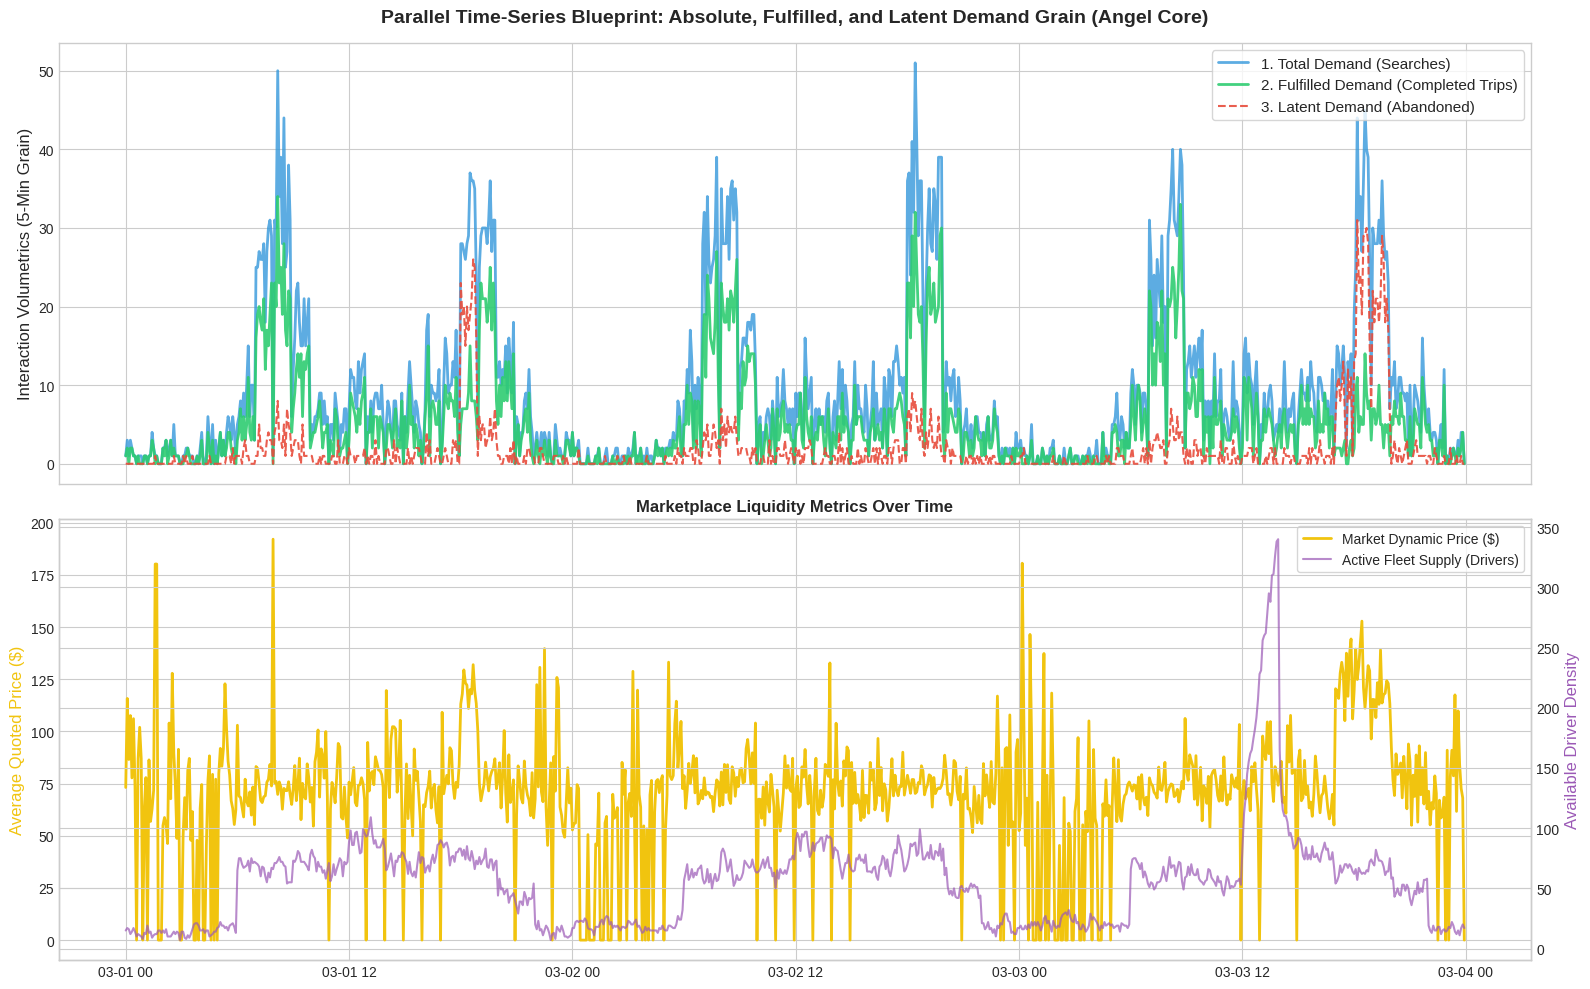

In [4]:
# ==============================================================================
# MODULE 1.3: VISUAL MARKETPLACE TIME-SERIES DEPLOYMENT
# Objective: Plot the 3 official parallel time-series to identify visual trends,
# peak imbalances, and latent demand spikes within the target corridor.
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set clean styling for professional documentation
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# ------------------------------------------------------------------------------
# PLOT 1: THE THREE PARALLEL MOBILITY SERIES (First 3 Days Window for Clarity)
# ------------------------------------------------------------------------------
# We zoom into a 3-day slice so the 5-min granular lines don't turn into solid black ink
sample_slice = df_official_ts.loc['2026-03-01':'2026-03-03']

ax1.plot(sample_slice.index, sample_slice['total_demand'], label='1. Total Demand (Searches)', color='#3498db', linewidth=2, alpha=0.8)
ax1.plot(sample_slice.index, sample_slice['fulfilled_demand'], label='2. Fulfilled Demand (Completed Trips)', color='#2ecc71', linewidth=2, alpha=0.9)
ax1.plot(sample_slice.index, sample_slice['latent_demand'], label='3. Latent Demand (Abandoned)', color='#e74c3c', linewidth=1.5, linestyle='--', alpha=0.9)

ax1.set_title('Parallel Time-Series Blueprint: Absolute, Fulfilled, and Latent Demand Grain (Angel Core)', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Interaction Volumetrics (5-Min Grain)', fontsize=12)
ax1.legend(loc='upper right', frameon=True, fontsize=11)

# ------------------------------------------------------------------------------
# PLOT 2: MARKETPLACE LIQUIDITY CORRELATION (Price vs Supply Density)
# ------------------------------------------------------------------------------
ax2.plot(sample_slice.index, sample_slice['avg_price_quoted'], label='Market Dynamic Price ($)', color='#f1c40f', linewidth=2)
ax2_twin = ax2.twinx()
ax2_twin.plot(sample_slice.index, sample_slice['supply_density'], label='Active Fleet Supply (Drivers)', color='#9b59b6', linewidth=1.5, alpha=0.7)

ax2.set_ylabel('Average Quoted Price ($)', fontsize=12, color='#f1c40f')
ax2_twin.set_ylabel('Available Driver Density', fontsize=12, color='#9b59b6')
ax2.set_title('Marketplace Liquidity Metrics Over Time', fontsize=12, fontweight='bold')

# Join legends for the twin-axes subplot
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True)

plt.xlabel('Chronological Timeline (March 2026)', fontsize=12)
plt.tight_layout()
plt.show()
